<a href="https://colab.research.google.com/github/MMujtabaX/CV-OD/blob/main/CV_OD_C16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV - Object Detection and Beyond
## Framework: Pytorch | Model: YOLO

In [ ]:
# !pip install ultralytics pillow torch torchvision torchaudio opencv-python matplotlib segmentation-models-pytorch albumentations -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os
import requests
import glob as glob

import torch
import cv2
from PIL import Image
from ultralytics import YOLO

In [ ]:
def download_file(url, save_name):
    file = requests.get(url)
    open(save_name, 'wb').write(file.content)

In [ ]:
def unzip(zip_file=None):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")

In [ ]:
# download_file(
#     'https://www.dropbox.com/s/h7l1lmhvga6miyo/object_detection_images.zip?dl=1',
#     'object_detection_images.zip'
# )

In [ ]:
# unzip(zip_file='object_detection_images.zip')

In [ ]:
image_paths = sorted(glob.glob('object_detection_images' + '/*.png'))

for idx in range(len(image_paths)):
    print(image_paths[idx])

object_detection_images/dog_bicycle_car.png
object_detection_images/elephants.png
object_detection_images/home_interior.png
object_detection_images/place_setting.png
object_detection_images/scene_man_dog.png


In [ ]:
def load_image(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [ ]:
images = [load_image(path) for path in image_paths]

In [ ]:
len(images)

5

In [ ]:
images[1][0][0]

array([189, 219, 237], dtype=uint8)

In [ ]:
def display_images(images):
    num_images = len(images)
    fig, axes = plt.subplots(nrows=num_images, ncols=1, figsize=(10, num_images * 5))
    if num_images == 1:
        axes = [axes]
    for i, axis in enumerate(axes):
        axis.imshow(images[i])
        axis.axis('off')
    plt.tight_layout()
    plt.show()

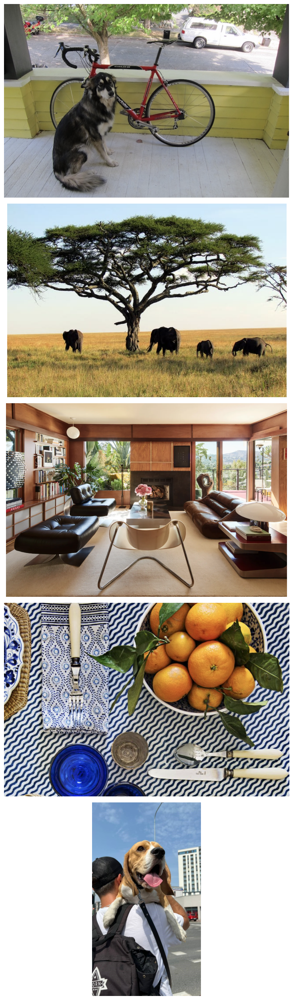

In [ ]:
display_images(images)

## 1. Object Detection using YOLO

In [ ]:
model_od = YOLO('yolo_models/yolo11l.pt')

In [ ]:
results = [model_od(img)[0].plot() for img in images]


0: 448x640 1 bicycle, 1 truck, 1 dog, 19.8ms
Speed: 1.6ms preprocess, 19.8ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 4 elephants, 12.2ms
Speed: 2.1ms preprocess, 12.2ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 chairs, 2 couchs, 2 potted plants, 5 books, 1 vase, 13.7ms
Speed: 1.9ms preprocess, 13.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 cup, 1 fork, 1 knife, 2 spoons, 3 bowls, 1 dining table, 13.8ms
Speed: 1.7ms preprocess, 13.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 640x384 1 person, 1 car, 1 dog, 1 backpack, 18.4ms
Speed: 1.5ms preprocess, 18.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)


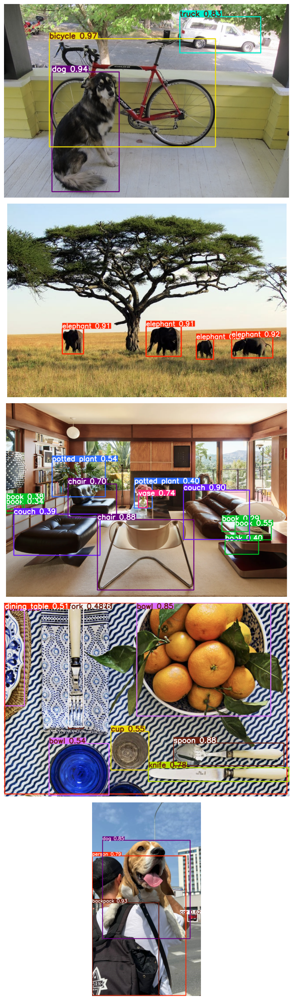

In [ ]:
display_images(results)

# 2. Instance Segmentation

In [ ]:
model_seg = YOLO('yolo_models/yolov8l-seg.pt')

In [ ]:
results_seg = [model_seg(img)[0].plot() for img in images]


0: 448x640 1 bicycle, 1 truck, 1 dog, 32.5ms
Speed: 1.9ms preprocess, 32.5ms inference, 8.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 horse, 4 elephants, 19.5ms
Speed: 1.8ms preprocess, 19.5ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 3 chairs, 1 couch, 2 potted plants, 4 books, 1 vase, 19.8ms
Speed: 2.0ms preprocess, 19.8ms inference, 2.6ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 cups, 1 fork, 2 knifes, 1 spoon, 1 bowl, 1 dining table, 15.3ms
Speed: 1.6ms preprocess, 15.3ms inference, 3.4ms postprocess per image at shape (1, 3, 448, 640)

0: 640x384 1 person, 1 car, 1 dog, 2 backpacks, 34.5ms
Speed: 1.4ms preprocess, 34.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 384)


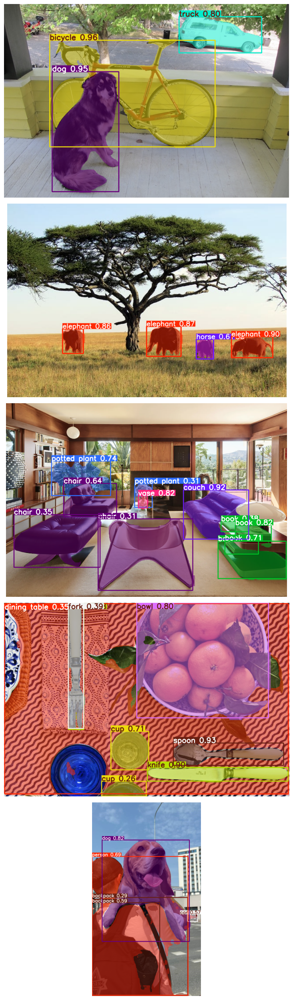

In [ ]:
display_images(results_seg)

# 3. Understanding results

In [ ]:
results = model_od(images)


0: 640x640 1 bicycle, 1 truck, 1 dog, 1 cup, 52.7ms
1: 640x640 4 elephants, 52.7ms
2: 640x640 2 chairs, 2 couchs, 2 potted plants, 5 books, 1 vase, 52.7ms
3: 640x640 2 cups, 1 fork, 1 knife, 2 spoons, 3 bowls, 1 orange, 1 dining table, 52.7ms
4: 640x640 1 person, 1 car, 1 dog, 1 backpack, 52.7ms
Speed: 2.9ms preprocess, 52.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
results[4]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [ ]:
results[4].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([24., 16.,  0.,  2.], device='cuda:0')
conf: tensor([0.9079, 0.8611, 0.7583, 0.6092], device='cuda:0')
data: tensor([[0.0000e+00, 6.6445e+02, 4.4110e+02, 1.2793e+03, 9.0789e-01, 2.4000e+01],
        [7.1861e+01, 2.5073e+02, 6.4749e+02, 8.9185e+02, 8.6108e-01, 1.6000e+01],
        [1.7959e+00, 3.5377e+02, 6.2071e+02, 1.2766e+03, 7.5828e-01, 0.0000e+00],
        [6.3155e+02, 7.3732e+02, 6.9717e+02, 7.8752e+02, 6.0923e-01, 2.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1280, 720)
shape: torch.Size([4, 6])
xywh: tensor([[220.5522, 971.8800, 441.1045, 614.8550],
        [359.6752, 571.2890, 575.6282, 641.1166],
        [311.2524, 815.1763, 618.9131, 922.8052],
        [664.3605, 762.4230,  65.6191,  50.2030]], device='cuda:0')
xywhn: tensor([[0.3063, 0.7593, 0.6126, 0.4804],
        [0.4995, 0.4463, 0.7995, 0.5009],
        [0.4323, 0.6369, 0.8596, 0.7209],
        [0.9227, 0.5956, 0.0911, 0.0392]], 

In [ ]:
result = model_seg(images)


0: 640x640 1 bicycle, 1 truck, 1 dog, 17.2ms
1: 640x640 1 horse, 4 elephants, 17.2ms
2: 640x640 3 chairs, 1 couch, 2 potted plants, 4 books, 1 vase, 17.2ms
3: 640x640 2 cups, 1 fork, 2 knifes, 1 spoon, 1 bowl, 1 dining table, 17.2ms
4: 640x640 1 person, 1 car, 1 dog, 2 backpacks, 17.2ms
Speed: 30.1ms preprocess, 17.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
result[4]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair

In [ ]:
# maybe show one mask?

for r in result[4]:
    print(r.masks.data[0].sum())

tensor(41467, device='cuda:0')
tensor(77535, device='cuda:0')
tensor(44116, device='cuda:0')
tensor(711, device='cuda:0')
tensor(55847, device='cuda:0')


# 4. Inference Arguments

In [ ]:
model_seg = YOLO('yolo_models/yolov8l-seg.pt')

In [ ]:
result = model_seg(images[4],
                   conf=0.3,
                   # iou=0.7,
                   max_det=10,
                   # classes=[0]
                  )


0: 640x384 1 person, 1 car, 1 dog, 1 backpack, 235.8ms
Speed: 3.6ms preprocess, 235.8ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
result[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16.,  0., 24.,  2.], device='cuda:0')
conf: tensor([0.8189, 0.6921, 0.5939, 0.5718], device='cuda:0')
data: tensor([[6.6606e+01, 2.4801e+02, 6.4380e+02, 9.1986e+02, 8.1891e-01, 1.6000e+01],
        [2.6349e-01, 3.5764e+02, 6.3417e+02, 1.2758e+03, 6.9207e-01, 0.0000e+00],
        [1.3000e-01, 6.6293e+02, 4.4757e+02, 1.2785e+03, 5.9395e-01, 2.4000e+01],
        [6.3102e+02, 7.3927e+02, 6.9828e+02, 7.8745e+02, 5.7179e-01, 2.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1280, 720)
shape: torch.Size([4, 6])
xywh: tensor([[355.2012, 583.9344, 577.1896, 671.8420],
        [317.2184, 816.7139, 633.9099, 918.1558],
        [223.8504, 970.7308, 447.4409, 615.6089],
        [664.6486, 763.3568,  67.2650,  48.1794]], device='cuda:0')
xywhn: tensor([[0.4933, 0.4562, 0.8017, 0.5249],
        [0.4406, 0.6381, 0.8804, 0.7173],
        [0.3109, 0.7584, 0.6214, 0.4809],
        [0.9231, 0.5964, 0.0934, 0.0376]], 

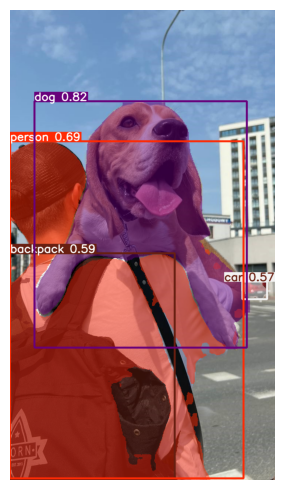

In [ ]:
results = []
results.append(result[0].plot())
display_images(results)

# 5. Detection Use Cases

## 5.1 Object Counting

In [ ]:
model_od = YOLO('yolo_models/yolov8m.pt')

In [ ]:
results = [model_od(img, conf=0.3)[0] for img in images]


0: 448x640 1 bicycle, 1 truck, 1 dog, 46.7ms
Speed: 2.0ms preprocess, 46.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 4 elephants, 8.5ms
Speed: 2.1ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 3 couchs, 1 potted plant, 3 books, 1 vase, 9.7ms
Speed: 2.7ms preprocess, 9.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 cups, 2 knifes, 1 spoon, 1 bowl, 1 dining table, 8.6ms
Speed: 1.7ms preprocess, 8.6ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)

0: 640x384 1 person, 1 car, 1 dog, 2 backpacks, 52.4ms
Speed: 1.9ms preprocess, 52.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
object_counts_list = []
for result in results:
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    unique, counts = np.unique(class_ids, return_counts=True)
    object_counts = {result.names[i]: count for i, count in zip(unique, counts)}
    object_counts_list.append(object_counts)

In [ ]:
for idx, obj_count in enumerate(object_counts_list):
    print(f"Image {idx + 1}: {obj_count}")

Image 1: {'bicycle': np.int64(1), 'truck': np.int64(1), 'dog': np.int64(1)}
Image 2: {'elephant': np.int64(4)}
Image 3: {'couch': np.int64(3), 'potted plant': np.int64(1), 'book': np.int64(3), 'vase': np.int64(1)}
Image 4: {'cup': np.int64(2), 'knife': np.int64(2), 'spoon': np.int64(1), 'bowl': np.int64(1), 'dining table': np.int64(1)}
Image 5: {'person': np.int64(1), 'car': np.int64(1), 'dog': np.int64(1), 'backpack': np.int64(2)}
